In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms
import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

import time

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


/bin/bash: line 1: nvidia-smi: command not found


In [3]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [4]:
def iter_gen(train_ind, valid_ind, test_ind, brain_signal_lfp, brain_region_index0, coordinate_list):

    data_test = TensorDataset(brain_signal_lfp[test_ind,:], brain_region_index0[test_ind], coordinate_list[test_ind])

    test_iter = DataLoader(data_test, batch_size=128, shuffle=True)

    return test_iter

In [5]:
def iter_subject_gen(train_ind, valid_ind, test_ind, test_subject_ind, brain_signal_lfp, brain_region_index0, coordinate_list):

    test_ind_od = test_subject_ind

    data_test = TensorDataset(brain_signal_lfp[test_ind_od,:], brain_region_index0[test_ind_od], coordinate_list[test_ind_od])

    test_iter_od = DataLoader(data_test, batch_size=128, shuffle=True)

    return test_iter_od

In [14]:
community_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/StimOn/community_stimOn_dict.pt', weights_only=False)
communities_accu_indiv = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/communities/StimOn/communities_stimOn_accu_indiv.pt', weights_only=False)
resolution = 1.0
marked_community = []
for community in np.unique(community_dict[resolution]['communities_label']):
    df_indiv0 = communities_accu_indiv[resolution][communities_accu_indiv[resolution]['acronym_test'] == community]
    for classifier_name in ['AnyNet']:
        if df_indiv0[df_indiv0['model_type'] == classifier_name]['acu_test'].mean() > 0.595:
            marked_community.append(community)

marked_community = np.unique(np.array(marked_community))

/tmp/ipython-input-601855737.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.barplot(


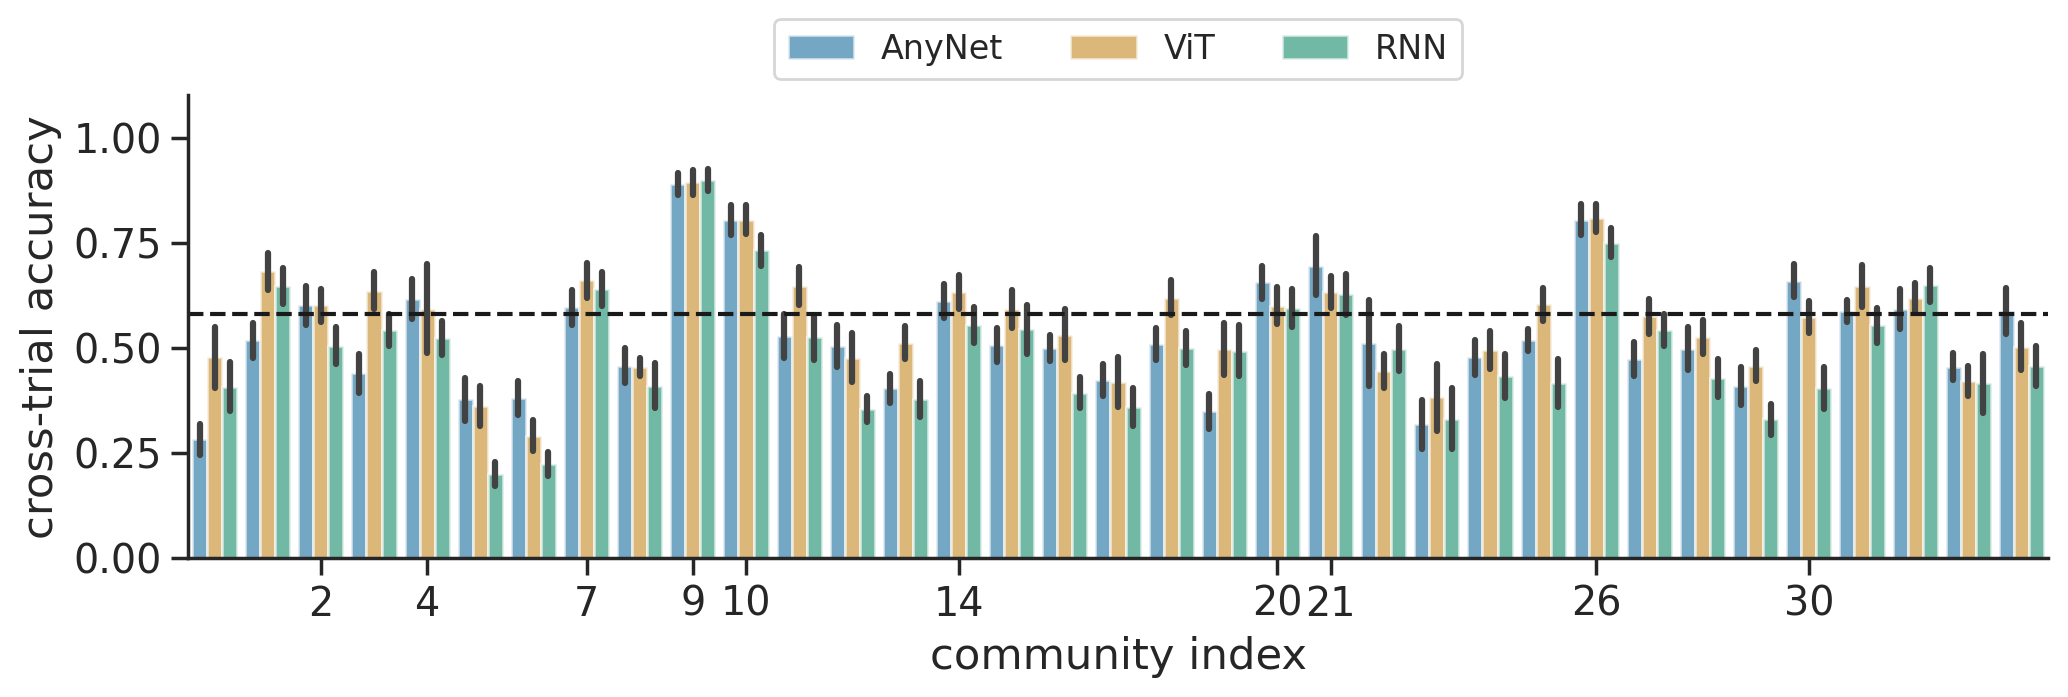

In [26]:
sns.set_theme(style='ticks', font_scale=1.3)
color_list = sns.color_palette('colorblind')
plt.figure(figsize=(12, 3), dpi=200)
g = sns.barplot(
    data=communities_accu_indiv[resolution],
    x='acronym_test', y='acu_test', hue='model_type',
    errorbar='sd', width=0.85, palette=color_list, alpha=.6
)
sns.move_legend(g, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, title=None, fontsize=12)
plt.plot([-0.5, 34.5], [0.58, 0.58], 'k--')
plt.xlim([-0.5, 34.5])
plt.ylim([0, 1.1])
plt.xticks(marked_community)
plt.ylabel('cross-trial accuracy')
plt.xlabel('community index')
sns.despine()
# plt.title('StimOn')
# plt.legend(loc='lower left')
plt.show()

In [21]:
for community_ii in np.unique(community_dict[1.0]['communities_label']):
    print(f'Commnity: {community_ii}')
    print('Allen:')
    print(community_dict[1.0]['communities_acronym'][np.argwhere(community_dict[1.0]['communities_label'] == community_ii).flatten()])


Commnity: 0
Allen:
['SSp-bfd2/3' 'TEa2/3' 'TEa4']
Commnity: 1
Allen:
['FRP5' 'FRP6a' 'MOs5' 'MOs6a' 'MOs6b' 'SSp-n2/3' 'VISC6b' 'ACAd5'
 'ACAd6a' 'ACAd6b' 'ACAv1' 'ACAv2/3' 'ACAv5' 'ACAv6a' 'ACAv6b' 'PL6a'
 'PL6b' 'ILA6a' 'AIp6b' 'IG' 'CP']
Commnity: 2
Allen:
['MOp5' 'MOp6a' 'MOp6b' 'SSp-n4' 'SSp-n6a' 'SSp-n6b' 'SSp-m6a' 'SSp-m6b'
 'ORBl5' 'ORBl6a' 'AId6a' 'AId6b' 'AIv5' 'AIv6a' 'AIv6b' 'CLA']
Commnity: 3
Allen:
['LSc' 'LSr' 'LSv' 'SF' 'SH' 'TRS' 'SFO' 'BST']
Commnity: 4
Allen:
['PL5' 'ILA1' 'ILA2/3' 'ILA5' 'ORBm5' 'ORBm6a' 'ORBvl6a']
Commnity: 5
Allen:
['VISpm5' 'VISpm6a' 'VISpm6b' 'RSPd6b' 'RSPv6b']
Commnity: 6
Allen:
['SSs2/3' 'VISp2/3' 'VISpl6a' 'RSPv6a']
Commnity: 7
Allen:
['VISp1' 'VISp4' 'VISp5' 'VISpl5' 'VISpm1' 'VISpm2/3' 'VISpm4' 'RSPagl2/3'
 'RSPagl5' 'RSPagl6a' 'RSPagl6b' 'RSPd1' 'RSPd2/3' 'RSPd5' 'RSPd6a'
 'RSPv2/3' 'VISa2/3' 'VISa4' 'VISa5' 'VISa6b' 'APr' 'SCop' 'SCsg' 'SCzo'
 'POST']
Commnity: 8
Allen:
['VISl1' 'VISl2/3' 'VISl4' 'VISl5' 'VISl6a' 'VISli2/3' 'VISli6b']
Com

In [22]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader

from iblatlas.atlas import AllenAtlas

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:01<00:00, 16.39it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:01<00:00,  3.85it/s]


In [24]:
community_dict[1.0]['communities']

array([ 21, 195, 196,   2,   3,  11,  12,  13,  15,  65, 127, 128, 129,
       130, 131, 132, 133, 134, 138, 139, 143, 163, 213, 236,   6,   7,
         8,  16,  18,  19,  36,  37, 146, 147, 157, 158, 165, 166, 167,
       226, 239, 240, 241, 242, 243, 255, 308, 441, 137, 140, 141, 142,
       150, 151, 155, 113, 114, 115, 177, 182,  56, 100, 109, 181,  99,
       101, 102, 108, 110, 111, 112, 169, 170, 171, 172, 173, 174, 175,
       176, 179, 184, 185, 186, 188, 225, 319, 320, 321, 435,  93,  94,
        95,  96,  97, 116, 120, 366, 385, 388, 389, 390, 391, 393, 394,
       395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 406, 407, 408,
       409, 410, 411, 412, 413, 415, 417, 418, 419, 420, 454, 455, 456,
       457, 458, 459, 460, 461, 462, 463, 464, 465, 467, 468, 469, 470,
       471, 258, 259, 260, 262, 264, 269, 273, 274, 276, 284, 297, 316,
       317, 318, 325, 328, 331, 332, 333, 335, 336, 337, 338, 340, 341,
       342, 343, 344, 346, 347, 350, 351, 355, 357, 358, 360, 36

In [28]:
acronym_list_Cosmos = [br.acronym2acronym(acronym, mapping='Cosmos')[0] for acronym in acronym_list]
acronym_list_Cosmos = np.array(acronym_list_Cosmos)
for community_ii in np.unique(community_dict[1.0]['communities_label']):
    print(f'Commnity: {community_ii}')
    print('Allen:')
    print(community_dict[1.0]['communities_acronym'][np.argwhere(community_dict[1.0]['communities_label'] == community_ii).flatten()])
    print('Cosmos:')
    print(acronym_list_Cosmos[community_dict[1.0]['communities'][np.argwhere(community_dict[1.0]['communities_label'] == community_ii).flatten()]])


Commnity: 0
Allen:
['SSp-bfd2/3' 'TEa2/3' 'TEa4']
Cosmos:
['Isocortex' 'Isocortex' 'Isocortex']
Commnity: 1
Allen:
['FRP5' 'FRP6a' 'MOs5' 'MOs6a' 'MOs6b' 'SSp-n2/3' 'VISC6b' 'ACAd5'
 'ACAd6a' 'ACAd6b' 'ACAv1' 'ACAv2/3' 'ACAv5' 'ACAv6a' 'ACAv6b' 'PL6a'
 'PL6b' 'ILA6a' 'AIp6b' 'IG' 'CP']
Cosmos:
['Isocortex' 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex'
 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex'
 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex'
 'Isocortex' 'HPF' 'CNU']
Commnity: 2
Allen:
['MOp5' 'MOp6a' 'MOp6b' 'SSp-n4' 'SSp-n6a' 'SSp-n6b' 'SSp-m6a' 'SSp-m6b'
 'ORBl5' 'ORBl6a' 'AId6a' 'AId6b' 'AIv5' 'AIv6a' 'AIv6b' 'CLA']
Cosmos:
['Isocortex' 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex'
 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex' 'Isocortex'
 'Isocortex' 'Isocortex' 'Isocortex' 'CTXsp']
Commnity: 3
Allen:
['LSc' 'LSr' 'LSv' 'SF' 'SH' 'TRS' 'SFO' 'BST']
Cosmos:
['CNU' 'CNU' 'CNU' 'CNU' 'CNU